####BANK LOAN ANALYSIS

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px

In [3]:
df = pd.read_csv("/content/financial_loan.csv")

Exploring Data
With head function, will be able to view the first 5 rows and with tail function will be able to view last 5 rows of the data.

In [4]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,11-02-2021,13-09-2021,13-04-2021,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,01-01-2021,14-12-2021,15-01-2021,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,05-01-2021,12-12-2021,09-01-2021,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,25-02-2021,12-12-2021,12-03-2021,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,01-01-2021,14-12-2021,15-01-2021,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [5]:
df.tail()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
38571,803452,NJ,INDIVIDUAL,< 1 year,Joseph M Sanzari Company,C,MORTGAGE,11-07-2021,16-05-2021,16-05-2021,...,C1,60 months,Verified,100000.0,0.1986,551.64,0.1299,24250,33,31946
38572,970377,NY,INDIVIDUAL,8 years,Swat Fame,C,RENT,11-10-2021,16-04-2021,16-05-2021,...,C1,60 months,Verified,50000.0,0.0458,579.72,0.1349,25200,18,31870
38573,875376,CA,INDIVIDUAL,5 years,Anaheim Regional Medical Center,D,RENT,11-09-2021,16-05-2021,16-05-2021,...,D5,60 months,Verified,65000.0,0.1734,627.93,0.1749,25000,20,35721
38574,972997,NY,INDIVIDUAL,5 years,Brooklyn Radiology,D,RENT,11-10-2021,16-05-2021,16-05-2021,...,D5,60 months,Verified,368000.0,0.0009,612.72,0.1825,24000,9,33677
38575,682952,NY,INDIVIDUAL,4 years,Allen Edmonds,F,RENT,11-07-2021,16-05-2021,16-05-2021,...,F3,60 months,Verified,80000.0,0.0600,486.86,0.2099,18000,7,27679


##Metadata data of data

In [6]:
print("No. of Rows:", df.shape[0])

No. of Rows: 38576


In [7]:
print("No. of Columns:", df.shape[1])

No. of Columns: 24


For more information about the data

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     38576 non-null  int64  
 1   address_state          38576 non-null  object 
 2   application_type       38576 non-null  object 
 3   emp_length             38576 non-null  object 
 4   emp_title              37138 non-null  object 
 5   grade                  38576 non-null  object 
 6   home_ownership         38576 non-null  object 
 7   issue_date             38576 non-null  object 
 8   last_credit_pull_date  38576 non-null  object 
 9   last_payment_date      38576 non-null  object 
 10  loan_status            38576 non-null  object 
 11  next_payment_date      38576 non-null  object 
 12  member_id              38576 non-null  int64  
 13  purpose                38576 non-null  object 
 14  sub_grade              38576 non-null  object 
 15  te

##Data Types

In [9]:
df.dtypes

,0
id,int64
address_state,object
application_type,object
emp_length,object
emp_title,object
grade,object
home_ownership,object
issue_date,object
last_credit_pull_date,object
last_payment_date,object


In [10]:
df.describe()

,id,member_id,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
count,3.857600e+04,3.857600e+04,3.857600e+04,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000,38576.000000
mean,6.810371e+05,8.476515e+05,6.964454e+04,0.133274,326.862965,0.120488,11296.066855,22.132544,12263.348533
std,2.113246e+05,2.668105e+05,6.429368e+04,0.066662,209.092000,0.037164,7460.746022,11.392282,9051.104777
min,5.473400e+04,7.069900e+04,4.000000e+03,0.000000,15.690000,0.054200,500.000000,2.000000,34.000000
25%,5.135170e+05,6.629788e+05,4.150000e+04,0.082100,168.450000,0.093200,5500.000000,14.000000,5633.000000
50%,6.627280e+05,8.473565e+05,6.000000e+04,0.134200,283.045000,0.118600,10000.000000,20.000000,10042.000000
75%,8.365060e+05,1.045652e+06,8.320050e+04,0.185900,434.442500,0.145900,15000.000000,29.000000,16658.000000
max,1.077501e+06,1.314167e+06,6.000000e+06,0.299900,1305.190000,0.245900,35000.000000,90.000000,58564.000000


##Total Loan Applications

In [11]:
total_loan_application = df['id'].count()
print("Total Loan Applications:", total_loan_application)

Total Loan Applications: 38576


In [12]:
df['issue_date'] = pd.to_datetime(df['issue_date'], format = '%d-%m-%Y')

##Month to Date Total Loan Application

In [13]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_data = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]

mtd_total_loan_application = mtd_data['id'].count()

print(f"Month to Date Total Loan Application(for {latest_issue_date.strftime('%B %Y')}): {mtd_total_loan_application}")

Month to Date Total Loan Application(for December 2021): 4314


##Total Funded Amount

In [14]:
total_funded_amount = df['loan_amount'].sum()
total_funded_amount_in_millions = total_funded_amount / 1000000
print("Total Funded Amount : ${:.2f}M" .format(total_funded_amount_in_millions))

Total Funded Amount : $435.76M


##Month to Date Total Funded Amount

In [15]:
latest_issue_date = df['issue_date'].max()
latest_year = latest_issue_date.year
latest_month = latest_issue_date.month

mtd_date = df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month == latest_month)]

mtd_total_funded_amount = mtd_data['loan_amount'].sum()

mtd_total_funded_amount_in_millions = mtd_total_funded_amount / 1000000

print(f"Month to Date total funded amount (for {latest_issue_date.strftime('%B %Y')}) :", " ${:.2f}M" .format(mtd_total_funded_amount_in_millions))

Month to Date total funded amount (for December 2021) :  $53.98M


###Total Amount Received

In [16]:
total_amount_received = df['total_payment'].sum()
total_amount_received_in_millions = total_amount_received / 1000000
print("Total Amount Received ${:.2f}M".format(total_amount_received_in_millions))

Total Amount Received $473.07M


##Month to Date Total Amount Received

In [17]:
mtd_total_amount_received = mtd_data['total_payment'].sum()

mtd_total_amount_received_in_millions = mtd_total_amount_received / 1000000

print(f"Month to Date Total Amount Received (for {latest_issue_date.strftime('%B %Y')})", ": ${:.2f}M".format(mtd_total_amount_received_in_millions))

Month to Date Total Amount Received (for December 2021) : $58.07M


##Average Interest Rate

In [18]:
average_interest_rate = df['int_rate'].mean()

average_interest_rate_in_percentage = average_interest_rate * 100

print('Average Interest Rate : {:.2f}%'. format(average_interest_rate_in_percentage))

Average Interest Rate : 12.05%


##Average Debt to Income Ratio (DTI)

In [19]:
average_dti = df['dti'].mean()*100
print("Average Debt to Income : {:.2f}%".format(average_dti))

Average Debt to Income : 13.33%


##Good Loan Metrics
Loans which has fully paid or current status.

In [20]:
good_loan = df[df['loan_status'].isin(['Fully Paid','Current'])]

total_loan_application = df['id'].count()
total_good_loan_application = good_loan['id'].count()
good_loan_funded_amount = good_loan['loan_amount'].sum() / 1000000
good_loan_amount_received = good_loan['total_payment'].sum() / 1000000

good_loan_percentage = total_good_loan_application / total_loan_application * 100

print('Total Good Loan Applications : ', total_good_loan_application)
print('Total Good Loan Funded Amount : ${:.2f}M'.format(good_loan_funded_amount))
print('Total Good Loan Amount Received : ${:.2f}M'.format(good_loan_amount_received))
print('Good loan percentage : {:.2f}%'.format(good_loan_percentage))



Total Good Loan Applications :  33243
Total Good Loan Funded Amount : $370.22M
Total Good Loan Amount Received : $435.79M
Good loan percentage : 86.18%


##Bad Loans
Loan status - Charged Off

In [21]:
bad_loan = df[df['loan_status'].isin(['Charged Off'])]

total_loan_application = df['id'].count()
total_bad_loan_application = bad_loan['id'].count()
bad_loan_funded_amount = bad_loan['loan_amount'].sum() / 1000000
bad_loan_amount_received = bad_loan['total_payment'].sum() / 1000000

bad_loan_percentage = total_bad_loan_application / total_loan_application * 100

print('Total Bad Loan Applications : ', total_bad_loan_application)
print('Total bad Loan Funded Amount : ${:.2f}M'.format(bad_loan_funded_amount))
print('Total bad Loan Amount Received : ${:.2f}M'.format(bad_loan_amount_received))
print('Bad loan percentage : {:.2f}%'.format(bad_loan_percentage))

Total Bad Loan Applications :  5333
Total bad Loan Funded Amount : $65.53M
Total bad Loan Amount Received : $37.28M
Bad loan percentage : 13.82%


## Monthly Trends by Issue Date for Total Funded Amount

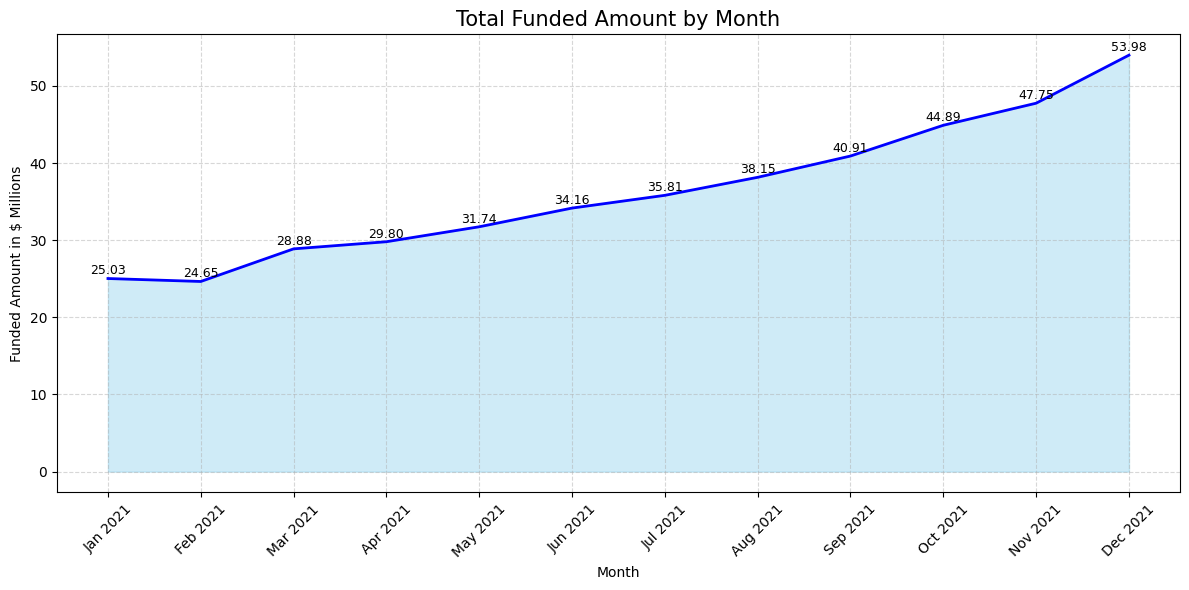

In [22]:
monthly_funded = (
    df.sort_values('issue_date')
    .assign(Month_name = lambda x: x['issue_date'].dt.strftime('%b %Y'))
    .groupby('Month_name',sort=False)['loan_amount']
    .sum()
    .div(1000000)
    .reset_index(name='loan_amount_in_millions')
)

plt.figure(figsize=(12,6))
plt.fill_between(monthly_funded['Month_name'],monthly_funded['loan_amount_in_millions'],color= 'skyblue', alpha = 0.4)
plt.plot(monthly_funded['Month_name'],monthly_funded['loan_amount_in_millions'], color = 'Blue', linewidth = 2)

for i, row in monthly_funded.iterrows():
  plt.text(i,row['loan_amount_in_millions'] + 1, f'{row['loan_amount_in_millions']:.2f}', ha='center', va = 'center', fontsize = 9 , rotation = 0, color = 'black')

plt.title('Total Funded Amount by Month', fontsize = 15)
plt.xlabel('Month')
plt.ylabel('Funded Amount in $ Millions')
plt.xticks(ticks=range(len(monthly_funded)), labels = monthly_funded['Month_name'], rotation = 45)
plt.grid(True, linestyle='--',alpha = 0.5)
plt.tight_layout()
plt.show()


##Monthly Trends by Issue Date for Total Amount Received

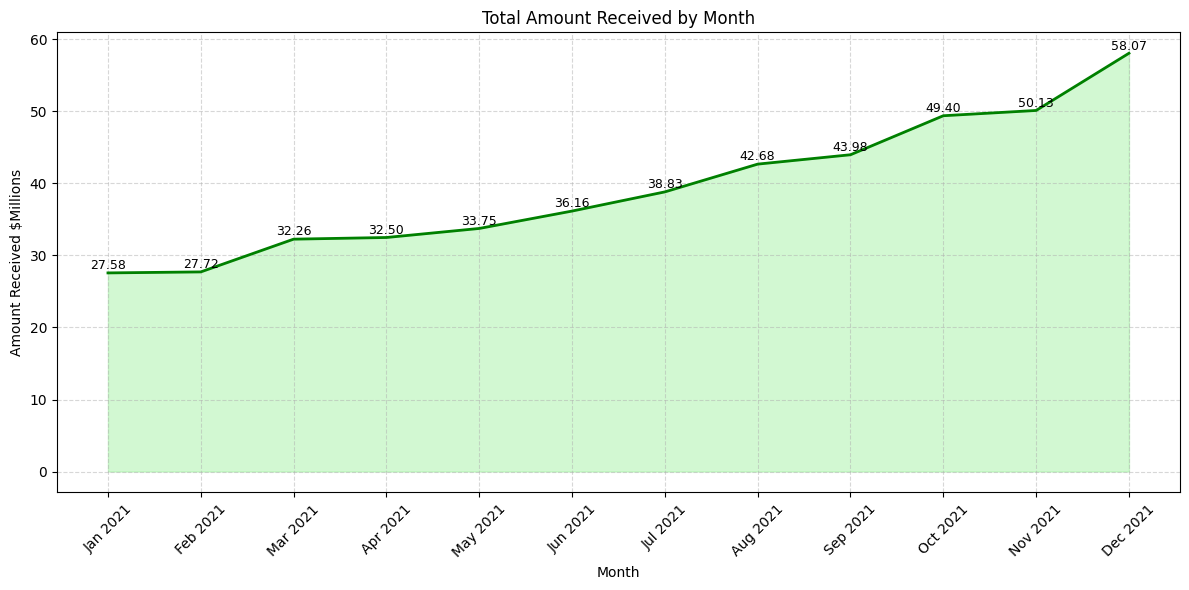

In [23]:
monthly_received = (
    df.sort_values('issue_date')
    .assign(month_name = lambda x: x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name', sort=False)['total_payment']
    .sum()
    .div(1000000)
    .reset_index(name = 'total_payment_millions')
)

plt.figure(figsize=(12,6))
plt.fill_between(monthly_received['month_name'],monthly_received['total_payment_millions'], color = 'lightgreen', alpha = 0.4)
plt.plot(monthly_received['month_name'],monthly_received['total_payment_millions'], color = 'green', linewidth = 2)

for i,row in monthly_received.iterrows():
  plt.text(i, row['total_payment_millions'] + 1, f'{row['total_payment_millions']:.2f}', color = 'black', ha='center', va='center', fontsize=9, rotation=0)

plt.title('Total Amount Received by Month')
plt.xlabel('Month')
plt.ylabel('Amount Received $Millions')
plt.xticks(ticks=range(len(monthly_received)), labels = monthly_received['month_name'], color = 'black', rotation = 45)
plt.grid(True, linestyle= '--', alpha = 0.5)
plt.tight_layout()
plt.show()

##Monthly Trend by Issue Date for Total Loan Applications

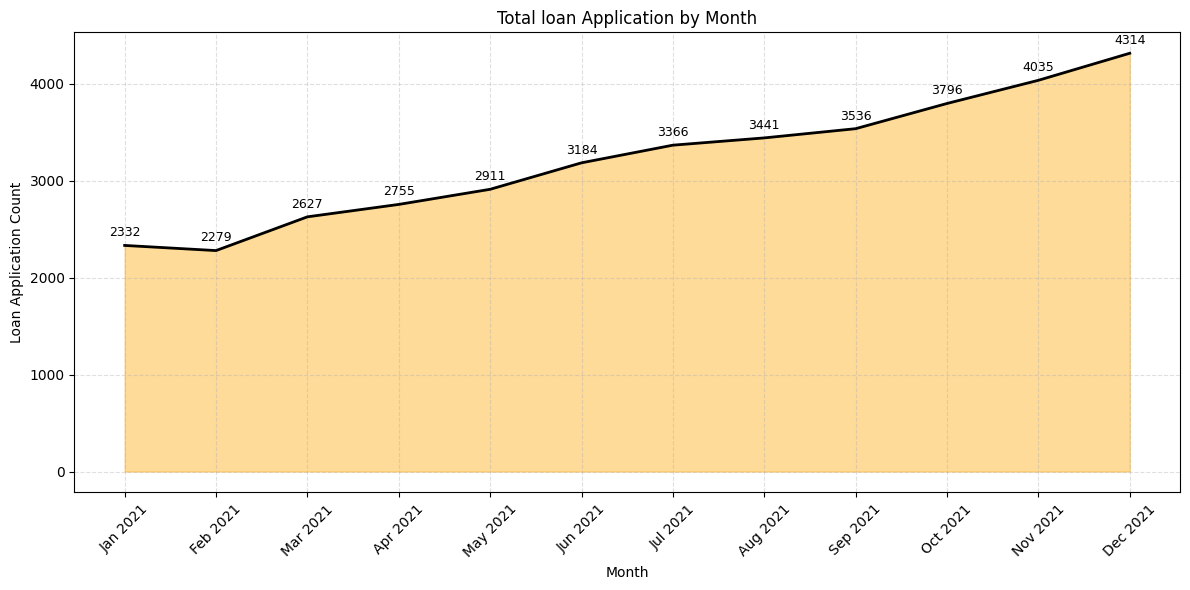

In [24]:
monthly_loan_application = (
    df.sort_values('issue_date')
    .assign(month_name = lambda x: x['issue_date'].dt.strftime('%b %Y'))
    .groupby('month_name', sort=False)['id']
    .count()
    .reset_index(name = 'loan_application_count')
)

plt.figure(figsize=(12,6))
plt.fill_between(monthly_loan_application['month_name'], monthly_loan_application['loan_application_count'], color = 'orange', alpha = 0.4)
plt.plot(monthly_loan_application['month_name'], monthly_loan_application['loan_application_count'], color = 'black', linewidth = 2)

for i, row in monthly_loan_application.iterrows():
  plt.text(i,row['loan_application_count'] + 130, f'{row['loan_application_count']}', ha='center', va='center', fontsize=9, rotation=0, color = 'black')

plt.title('Total loan Application by Month')
plt.xlabel('Month')
plt.ylabel('Loan Application Count')
plt.xticks(ticks=range(len(monthly_loan_application)), labels = monthly_loan_application['month_name'], color = 'black', rotation = 45)
plt.grid(True, linestyle = '--', alpha = 0.4)
plt.tight_layout()
plt.show()

##Regional Analysis by State for Total Funded Amount

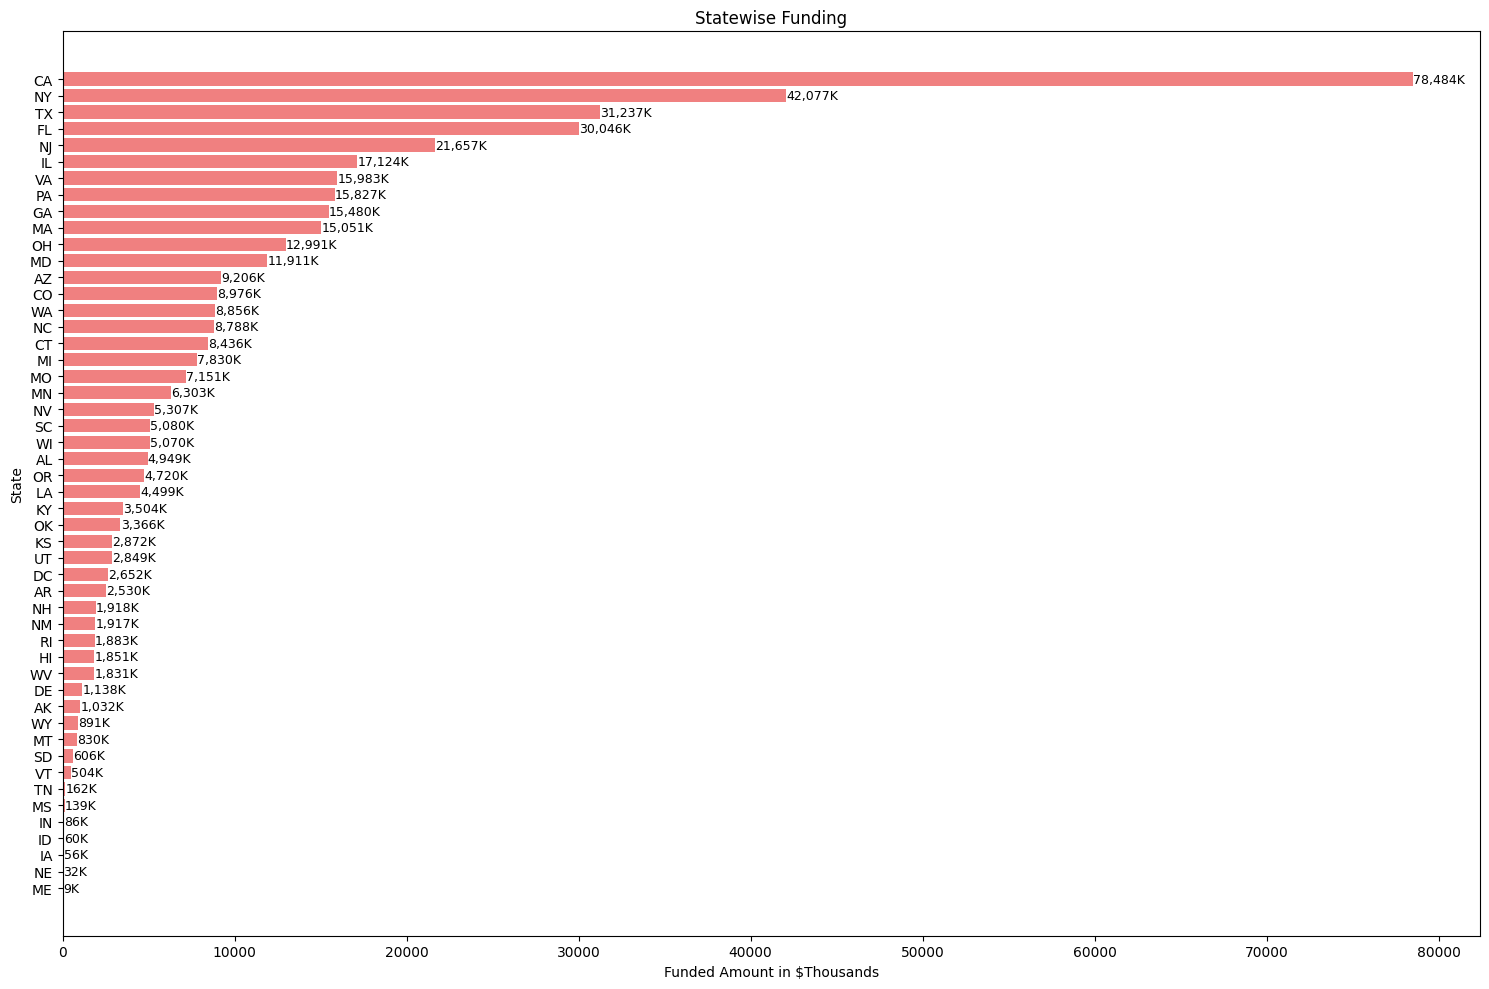

In [25]:
state_funding = df.groupby('address_state')['loan_amount'].sum().sort_values(ascending=True)
state_funding_thousands = state_funding.div(1000)

plt.figure(figsize=(15,10))
bars = plt.barh(state_funding_thousands.index, state_funding_thousands.values, color = 'lightcoral')

for bar in bars:
  width = bar.get_width()
  plt.text(width + 10, bar.get_y() + bar.get_height()/2, f'{width :,.0f}K', va='center', color = 'black', fontsize = 9)

plt.title('Statewise Funding')
plt.xlabel('Funded Amount in $Thousands')
plt.ylabel('State')
plt.tight_layout()
plt.show()

## Regional Analysis by State for Total Amount Received

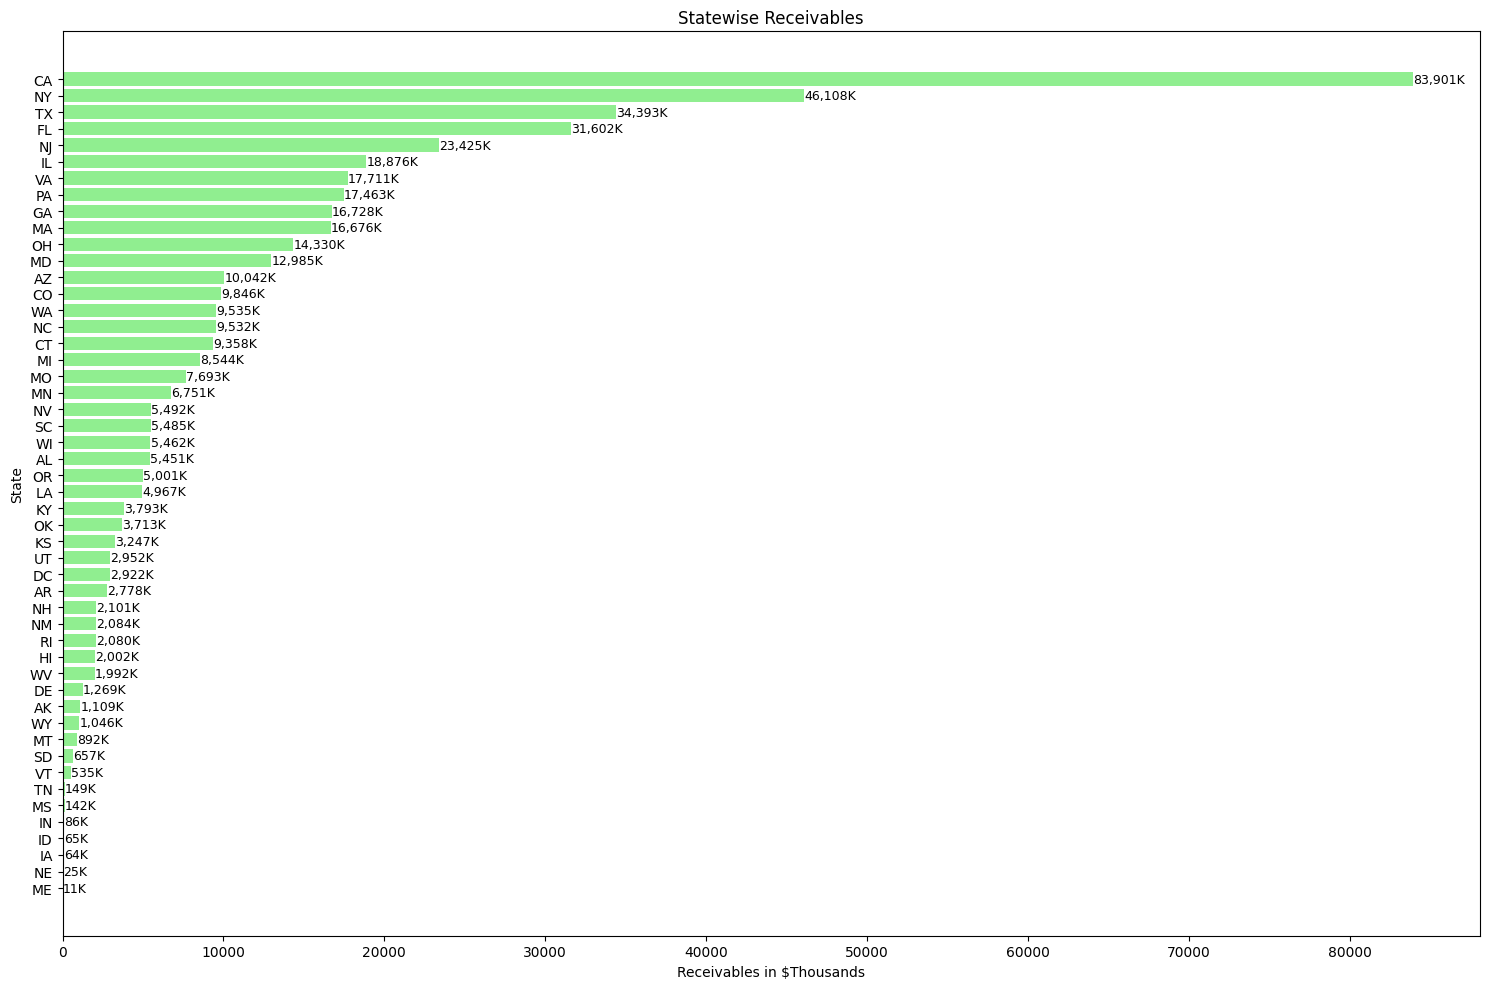

In [26]:
state_receivables = df.groupby('address_state')['total_payment'].sum().sort_values(ascending = True)
state_receivables_thousands = state_receivables.div(1000)

plt.figure(figsize=(15,10))
bars = plt.barh(state_funding_thousands.index, state_receivables_thousands.values, color = 'lightgreen')

for bar in bars:
  width = bar.get_width()
  plt.text(width + 10, bar.get_y() + bar.get_height()/2, f'{width :,.0f}K', va='center', color = 'black', fontsize = 9)

plt.title('Statewise Receivables')
plt.xlabel('Receivables in $Thousands')
plt.ylabel('State')
plt.tight_layout()
plt.show()

## Regional Analysis by State for Total Application

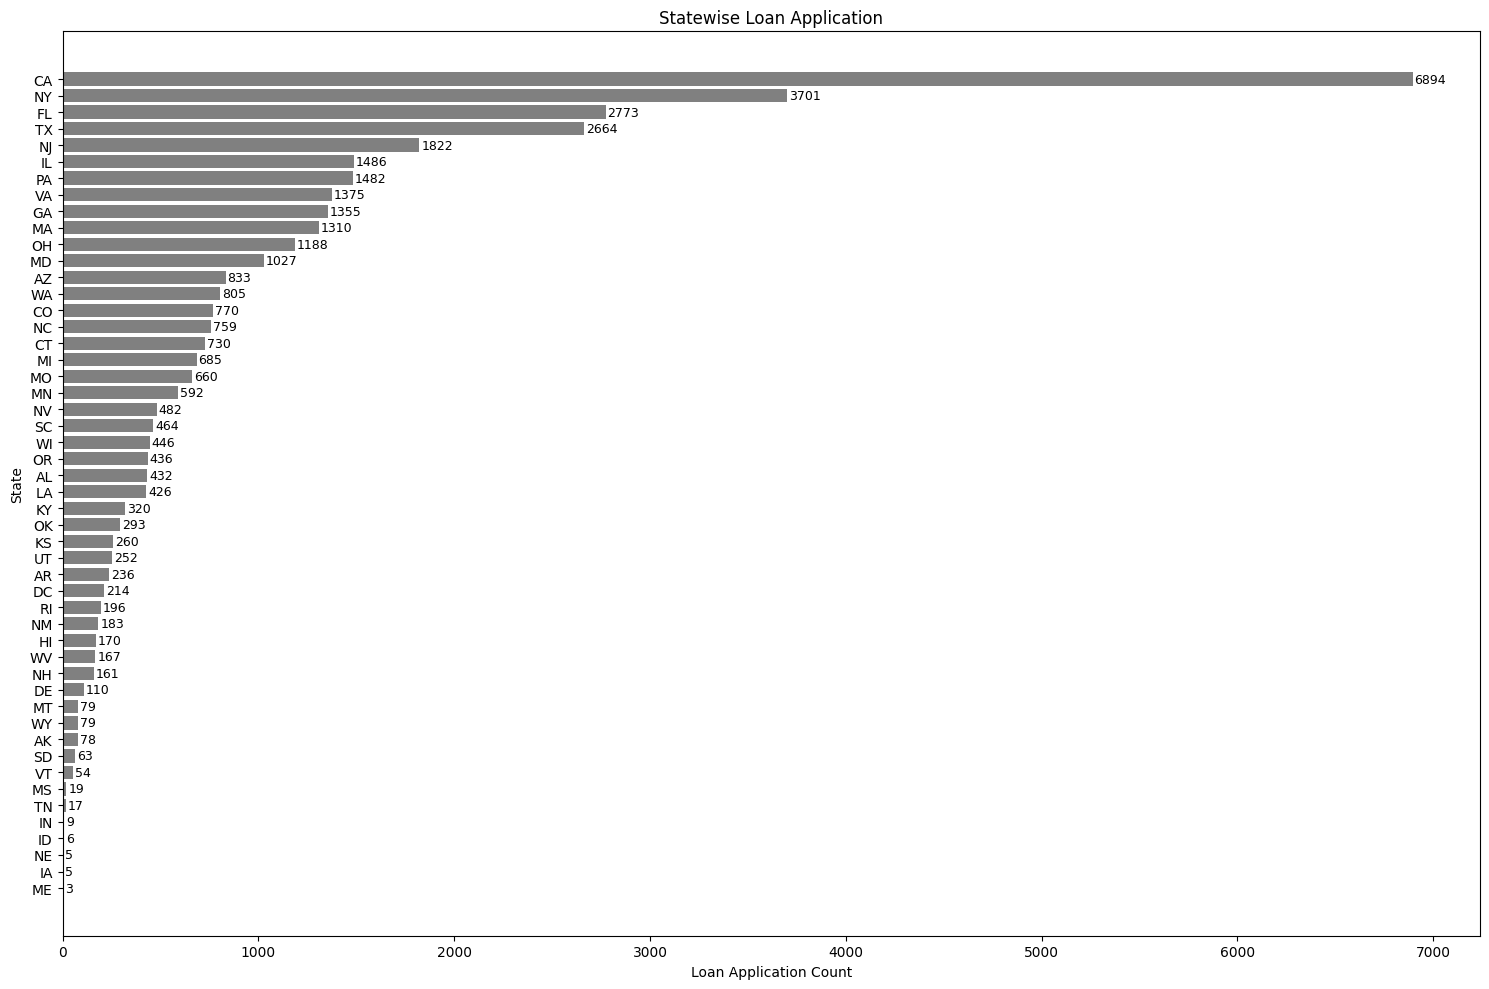

In [27]:
statewise_loan_application = df.groupby('address_state')['id'].count().sort_values(ascending = True)

plt.figure(figsize=(15,10))
bars = plt.barh(statewise_loan_application.index, statewise_loan_application.values, color = 'grey')

for bar in bars:
  width=bar.get_width()
  plt.text(width + 10, bar.get_y() + bar.get_height()/2, f'{width}', va='center', color = 'black', fontsize=9)

plt.title('Statewise Loan Application')
plt.xlabel('Loan Application Count')
plt.ylabel('State')
plt.tight_layout()
plt.show()

## Total Funded Amount by Loan Term(Donut Chart)

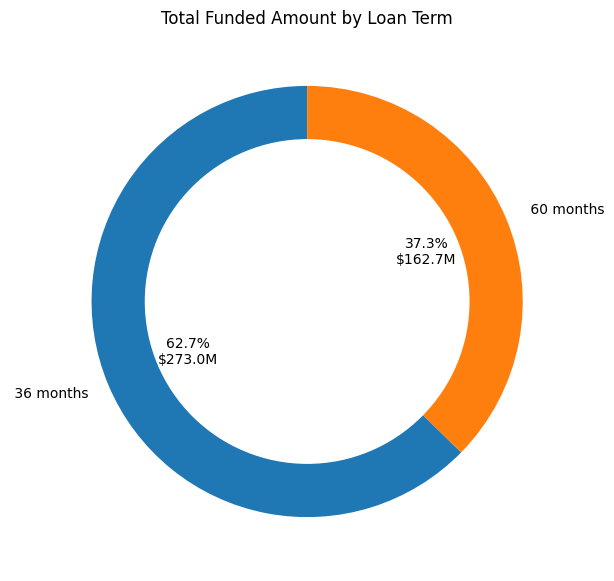

In [28]:
term_funding = df.groupby('term')['loan_amount'].sum().div(1000000)

plt.figure(figsize=(7,7))
plt.pie(
    term_funding,
    labels = term_funding.index,
    autopct= lambda p: f'{p:.1f}%\n${p*sum(term_funding)/100 :.1f}M',
    startangle = 90
)

plt.gca().add_artist(plt.Circle((0,0), 0.75, color = 'white'))
plt.title('Total Funded Amount by Loan Term')
plt.show()

##Total Amount Received by Loan Term

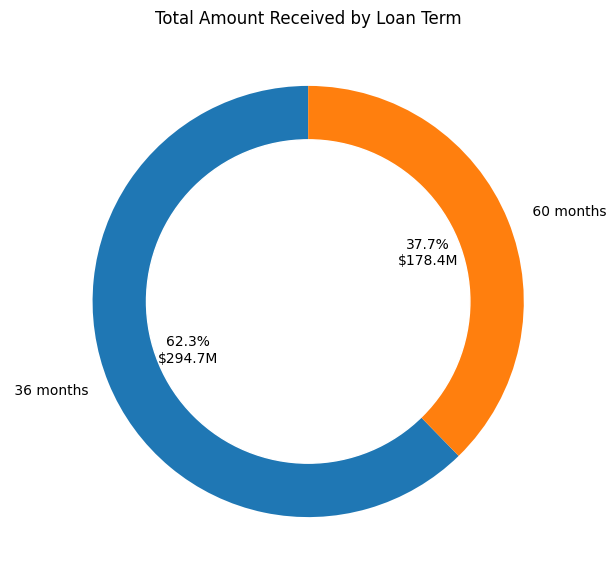

In [29]:
term_receivables = df.groupby('term')['total_payment'].sum().div(1000000)

plt.figure(figsize=(7,7))
plt.pie(
    term_receivables,
    labels = term_receivables.index,
    autopct= lambda p: f'{p:.1f}%\n${p*sum(term_receivables)/100 :.1f}M',
    startangle=90
)

plt.gca().add_artist(plt.Circle((0,0), 0.75, color = 'white'))
plt.title('Total Amount Received by Loan Term')
plt.show()

##Total Loan Application by Loan Term

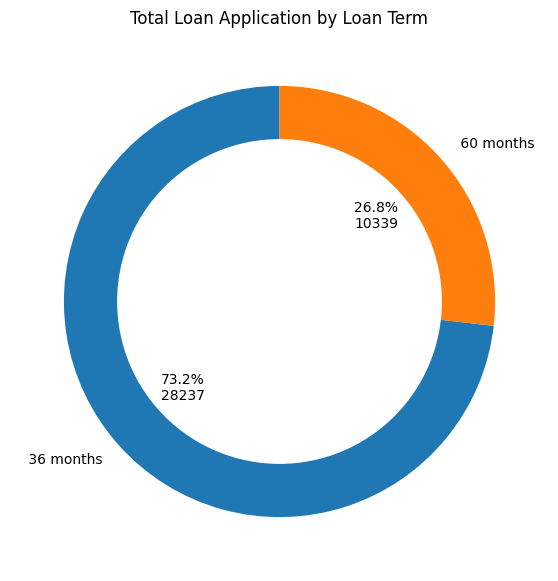

In [30]:
term_loan_application = df.groupby('term')['id'].count()

plt.figure(figsize=(7,7))
plt.pie(
    term_loan_application,
    labels = term_loan_application.index,
    autopct = lambda p: f'{p:.1f}%\n{p*sum(term_loan_application)/100 :.0f}',
    startangle=90
)

plt.gca().add_artist(plt.Circle((0,0),0.75, color = 'white'))
plt.title('Total Loan Application by Loan Term')
plt.show()

##Total Funded Amount by Employee Length

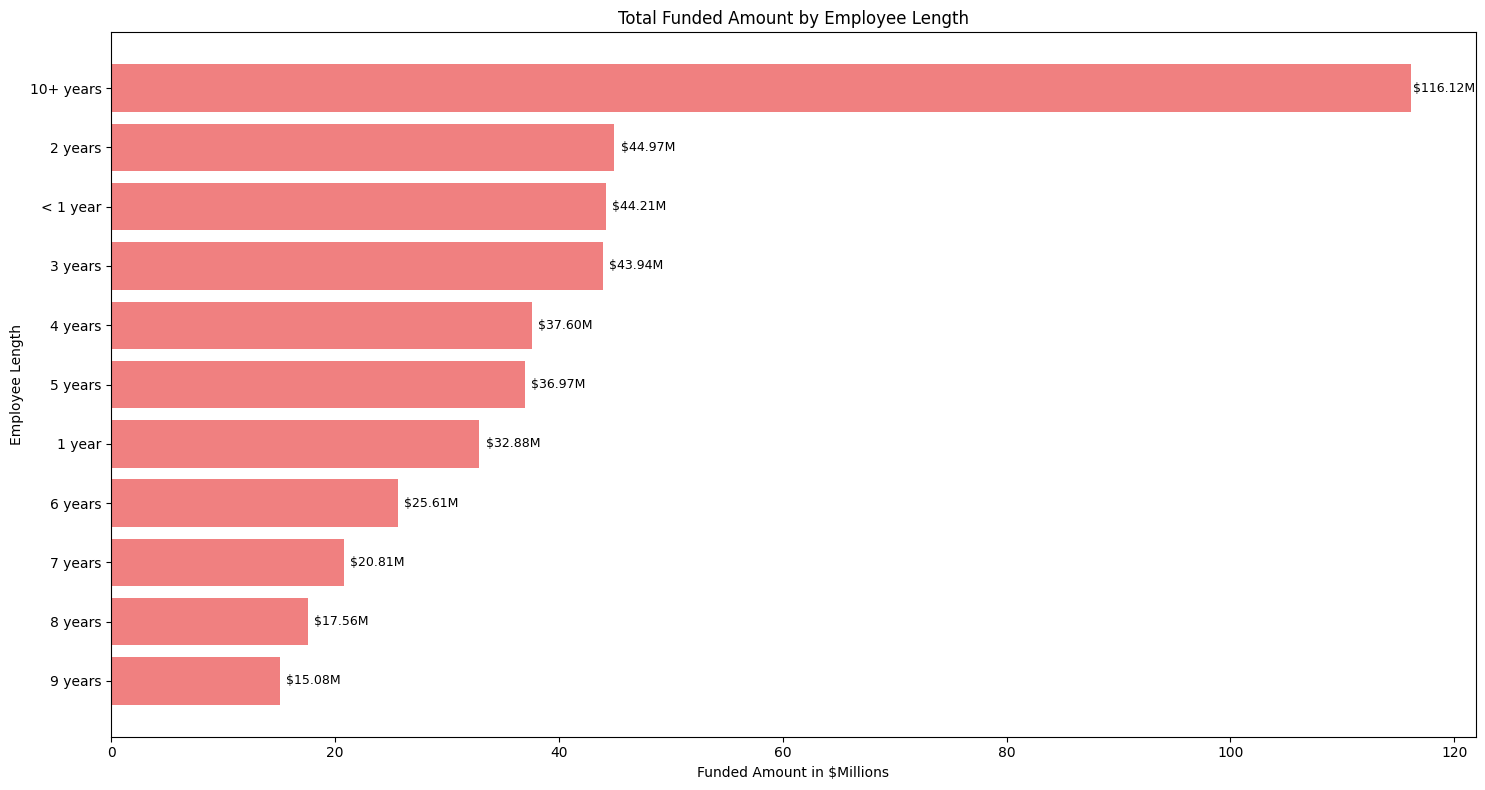

In [31]:
employee_length_funding = df.groupby('emp_length')['loan_amount'].sum().sort_values(ascending=True).div(1000000)

plt.figure(figsize=(15,8))
bars = plt.barh(employee_length_funding.index, employee_length_funding.values, color = 'lightcoral')

for bar in bars:
  width = bar.get_width()
  plt.text(width + 3, bar.get_y() + bar.get_height()/2, f'${width:.2f}M', ha='center', va='center', fontsize=9, color='black')

plt.title('Total Funded Amount by Employee Length')
plt.xlabel('Funded Amount in $Millions')
plt.ylabel('Employee Length')
plt.tight_layout()
plt.show()

##Total Amount Received by Employee Length

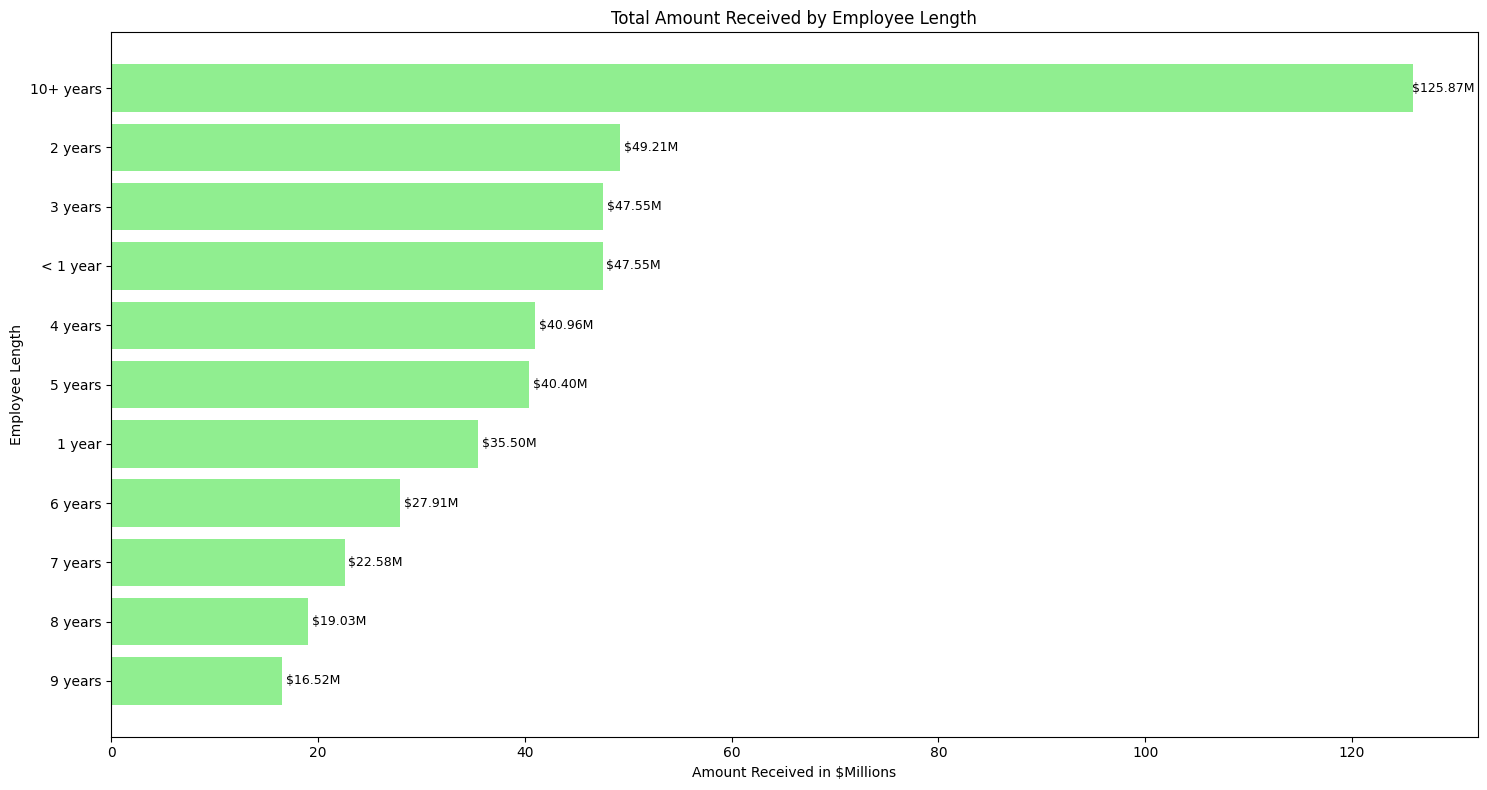

In [32]:
employee_length_receivables = df.groupby('emp_length')['total_payment'].sum().sort_values(ascending=True).div(1000000)

plt.figure(figsize=(15,8))
bars = plt.barh(employee_length_receivables.index, employee_length_receivables.values, color = 'lightgreen')

for bar in bars:
  width = bar.get_width()
  plt.text(width + 3, bar.get_y() + bar.get_height()/2, f'${width:.2f}M', ha='center', va='center', fontsize=9, color='black')

plt.title('Total Amount Received by Employee Length')
plt.xlabel('Amount Received in $Millions')
plt.ylabel('Employee Length')
plt.tight_layout()
plt.show()

##Total Loan Application by Employee Length

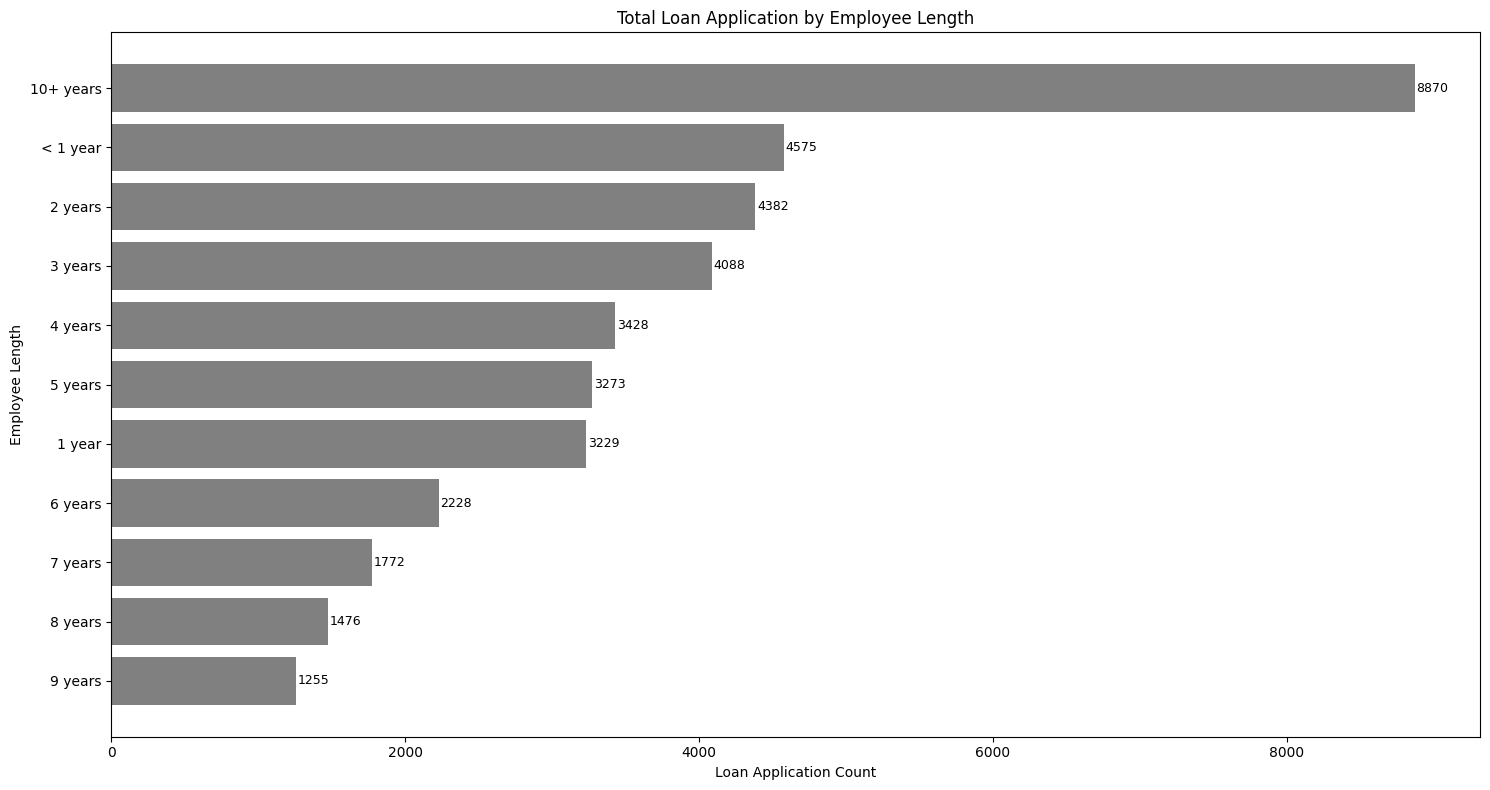

In [33]:
employee_length_loan_application = df.groupby('emp_length')['id'].count().sort_values(ascending=True)

plt.figure(figsize=(15,8))
bars = plt.barh(employee_length_loan_application.index, employee_length_loan_application.values, color = 'grey')

for bar in bars:
  width = bar.get_width()
  plt.text(width + 120, bar.get_y() + bar.get_height()/2, f'{width}', ha='center', va='center', fontsize=9, color='black')

plt.title('Total Loan Application by Employee Length')
plt.xlabel('Loan Application Count')
plt.ylabel('Employee Length')
plt.tight_layout()
plt.show()

##Total Funded Amount by Loan Purpose

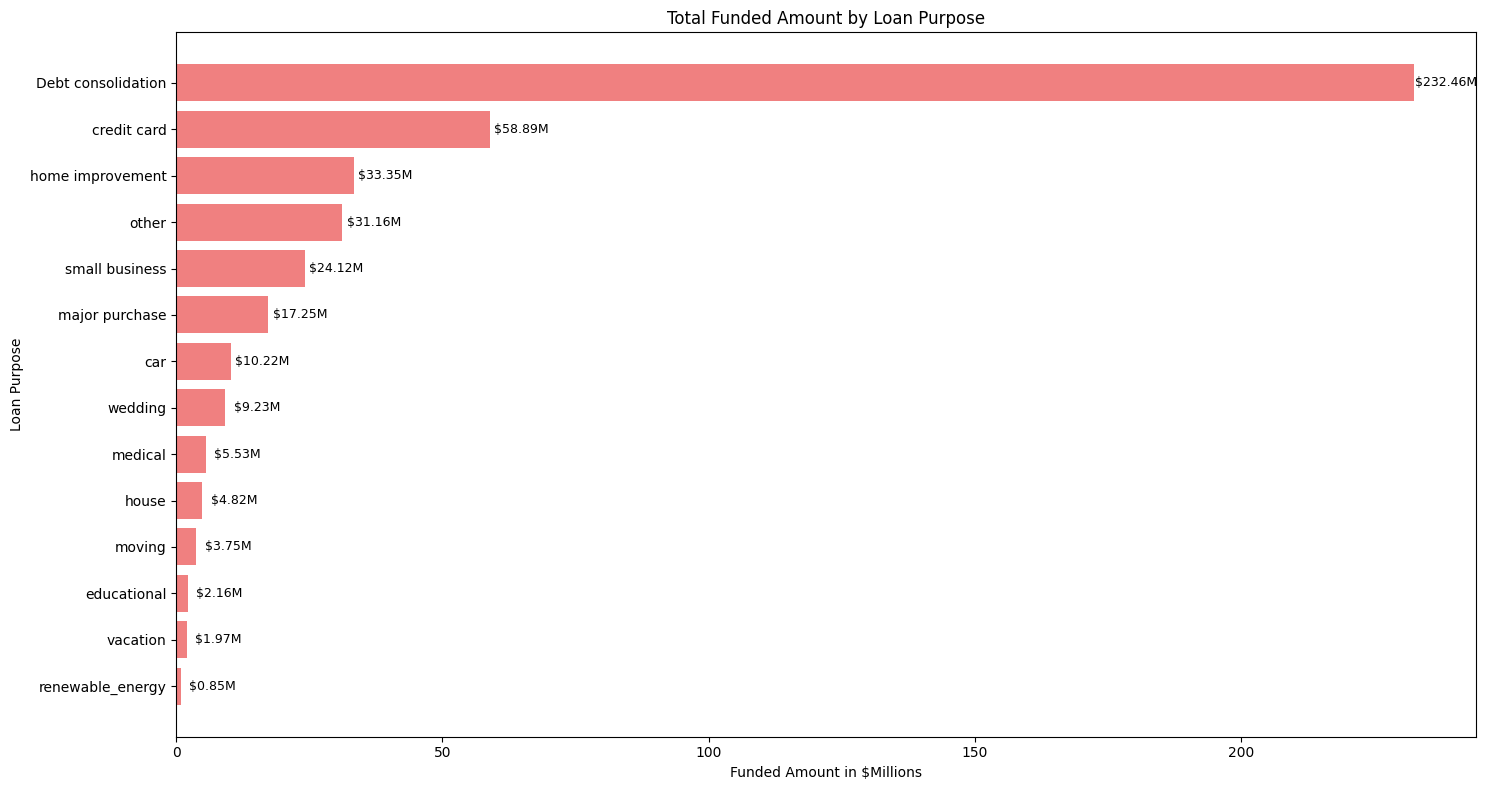

In [34]:
loan_purpose_funding = df.groupby('purpose')['loan_amount'].sum().sort_values(ascending=True).div(1000000)

plt.figure(figsize=(15,8))
bars = plt.barh(loan_purpose_funding.index, loan_purpose_funding.values, color = 'lightcoral')

for bar in bars:
  width = bar.get_width()
  plt.text(width + 6, bar.get_y() + bar.get_height()/2, f'${width:.2f}M', ha='center', va='center', fontsize=9, color='black')

plt.title('Total Funded Amount by Loan Purpose')
plt.xlabel('Funded Amount in $Millions')
plt.ylabel('Loan Purpose')
plt.tight_layout()
plt.show()

##Total Amount Received by Loan Purpose

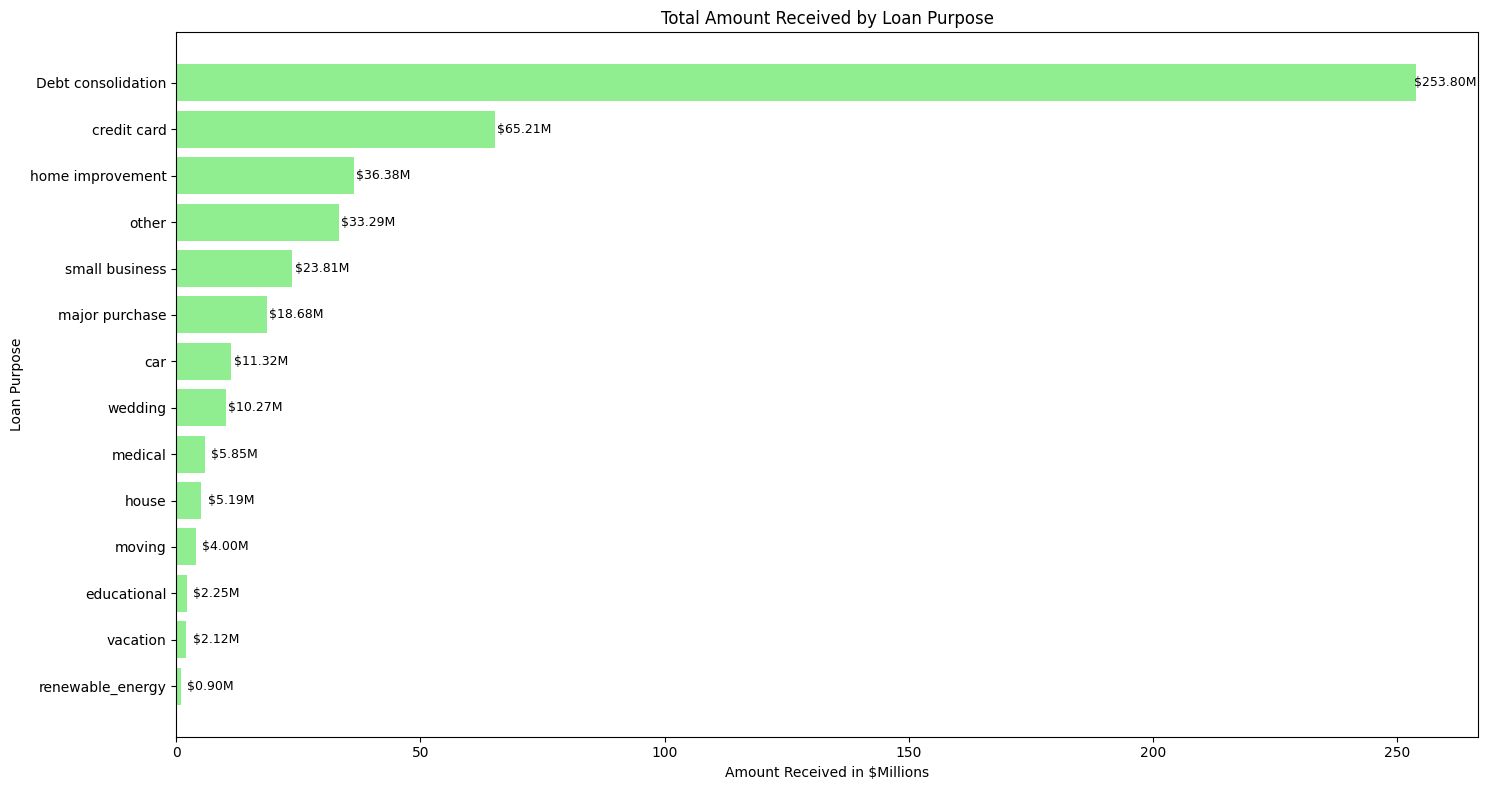

In [35]:
loan_purpose_receivables = df.groupby('purpose')['total_payment'].sum().sort_values(ascending=True).div(1000000)

plt.figure(figsize=(15,8))
bars = plt.barh(loan_purpose_receivables.index, loan_purpose_receivables.values, color = 'lightgreen')

for bar in bars:
  width = bar.get_width()
  plt.text(width + 6, bar.get_y() + bar.get_height()/2, f'${width:.2f}M', ha='center', va='center', fontsize=9, color='black')

plt.title('Total Amount Received by Loan Purpose')
plt.xlabel('Amount Received in $Millions')
plt.ylabel('Loan Purpose')
plt.tight_layout()
plt.show()

##Total Application by loan purpose

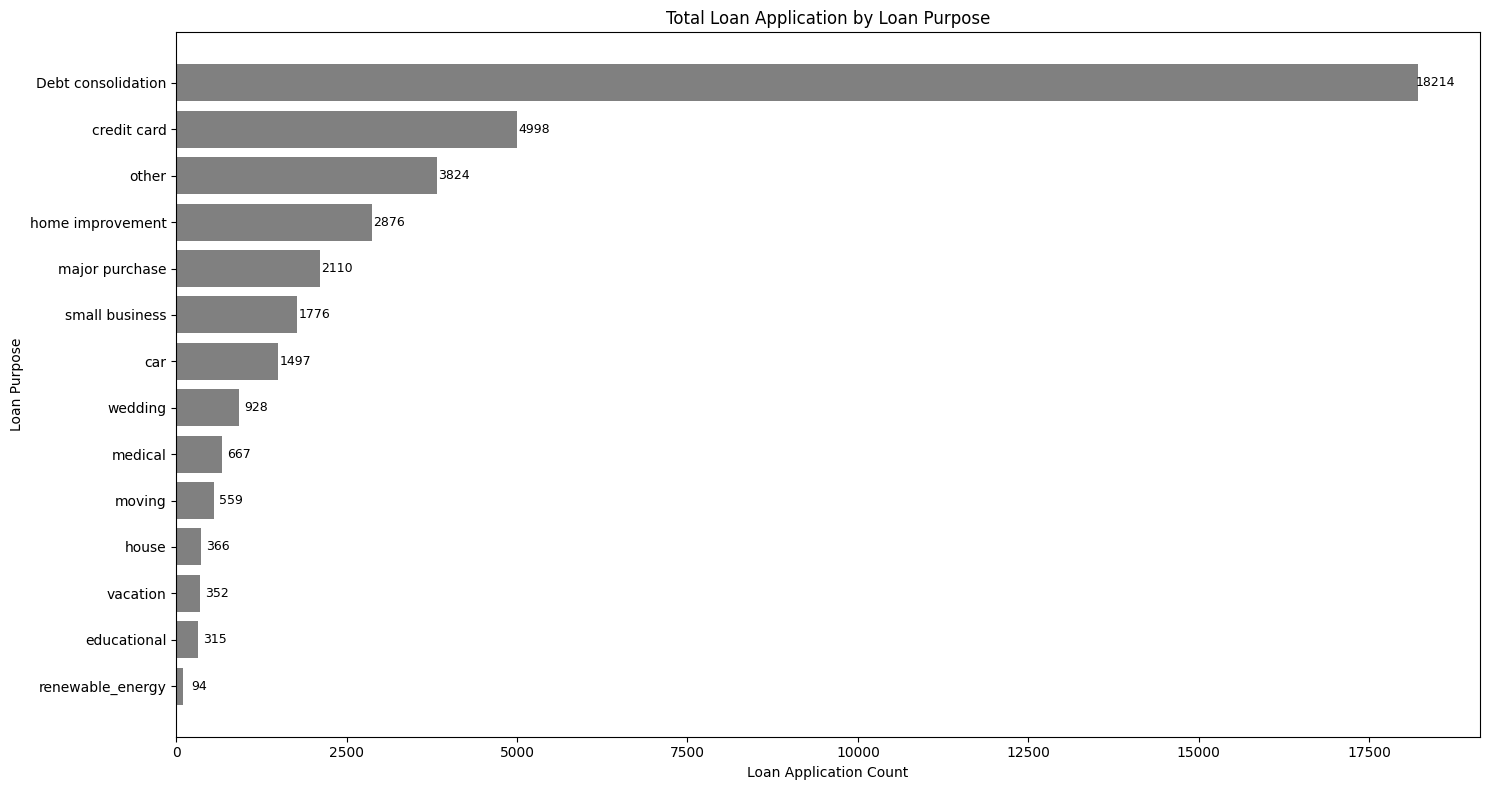

In [36]:
loan_purpose_application = df.groupby('purpose')['id'].count().sort_values(ascending=True)

plt.figure(figsize=(15,8))
bars = plt.barh(loan_purpose_application.index, loan_purpose_application.values, color = 'grey')

for bar in bars:
  width = bar.get_width()
  plt.text(width + 250, bar.get_y() + bar.get_height()/2, f'{width}', ha='center', va='center', fontsize=9, color='black')

plt.title('Total Loan Application by Loan Purpose')
plt.xlabel('Loan Application Count')
plt.ylabel('Loan Purpose')
plt.tight_layout()
plt.show()

##Total Funded Amount by Home Ownership

In [37]:
home_ownership_funding = df.groupby('home_ownership')['loan_amount'].sum().div(1000000).reset_index()

fig = px.treemap(
    home_ownership_funding,
    path =['home_ownership'],
    values = 'loan_amount',
    color= 'loan_amount',
    color_continuous_scale = 'Blues',
    title='Total Funded Amount by Home Ownership in $Millions'
)

fig.show()


##Amount Received by Home Ownership

In [38]:
home_ownership_receivables = df.groupby('home_ownership')['total_payment'].sum().div(1000000).reset_index()

fig = px.treemap(
    home_ownership_receivables,
    path = ['home_ownership'],
    values = 'total_payment',
    color = 'total_payment',
    color_continuous_scale = 'Greens',
    title = 'Totam Amount Received in $Millions'
)

fig.show()

##Total Loan Application based on Home Ownership

In [39]:
home_ownership_loan_application = df.groupby('home_ownership')['id'].count().reset_index()

fig = px.treemap(
    home_ownership_loan_application,
    path = ['home_ownership'],
    values = 'id',
    color = 'id',
    color_continuous_scale = 'Blues',
    title = 'Total Loan Application'
)

fig.show()